<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/4_Valores_at%C3%ADpicos_DataFrame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Cargar archivo csv desde equipo
from google.colab import files
files.upload()

In [2]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Citas_Digital_sin_nulos.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                674 non-null    int64  
 1   BDC                                       674 non-null    str    
 2   Fecha                                     674 non-null    str    
 3   Nombre Cliente                            674 non-null    str    
 4   Telefono                                  674 non-null    str    
 5   Estatus de Lead                           674 non-null    str    
 6   Potencial de compra                       674 non-null    float64
 7   PDM                                       674 non-null    float64
 8   SDC                                       674 non-null    float64
 9   Venta                                     674 non-null    float64
 10  Asesor Asignado                           674 non

In [ ]:
#Se elemina la columna 'Unnamed: 0' que es un índice innecesario
data.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       674 non-null    str    
 1   Fecha                                     674 non-null    str    
 2   Nombre Cliente                            674 non-null    str    
 3   Telefono                                  674 non-null    str    
 4   Estatus de Lead                           674 non-null    str    
 5   Potencial de compra                       674 non-null    float64
 6   PDM                                       674 non-null    float64
 7   SDC                                       674 non-null    float64
 8   Venta                                     674 non-null    float64
 9   Asesor Asignado                           674 non-null    str    
 10  ¿Por que no ha visitado la agencia?       674 non

In [11]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Telefono                                    0
Estatus de Lead                             0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
dtype: int64

In [12]:
#Creo 2 dataframe para poder procesar los outliers
# Variables cuantitativas: columnas 5 a 8
cuantitativas = data.iloc[:, 5:9]

# Variables cualitativas: columnas 0 a 4 y 9 a 14
cualitativas = pd.concat([
    data.iloc[:, 0:5],
    data.iloc[:, 9:15]
], axis=1)

<Figure size 1500x800 with 0 Axes>

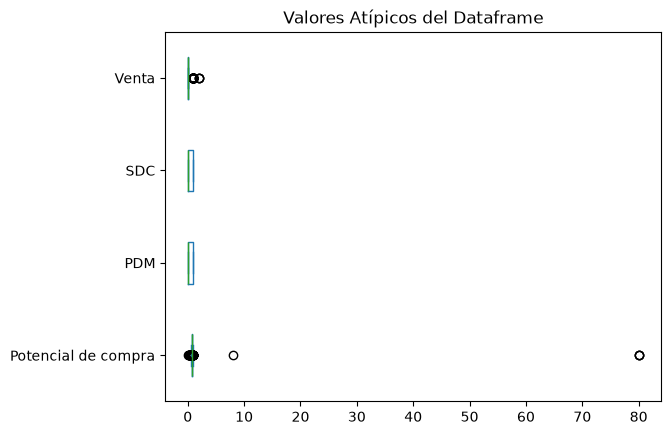

In [13]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

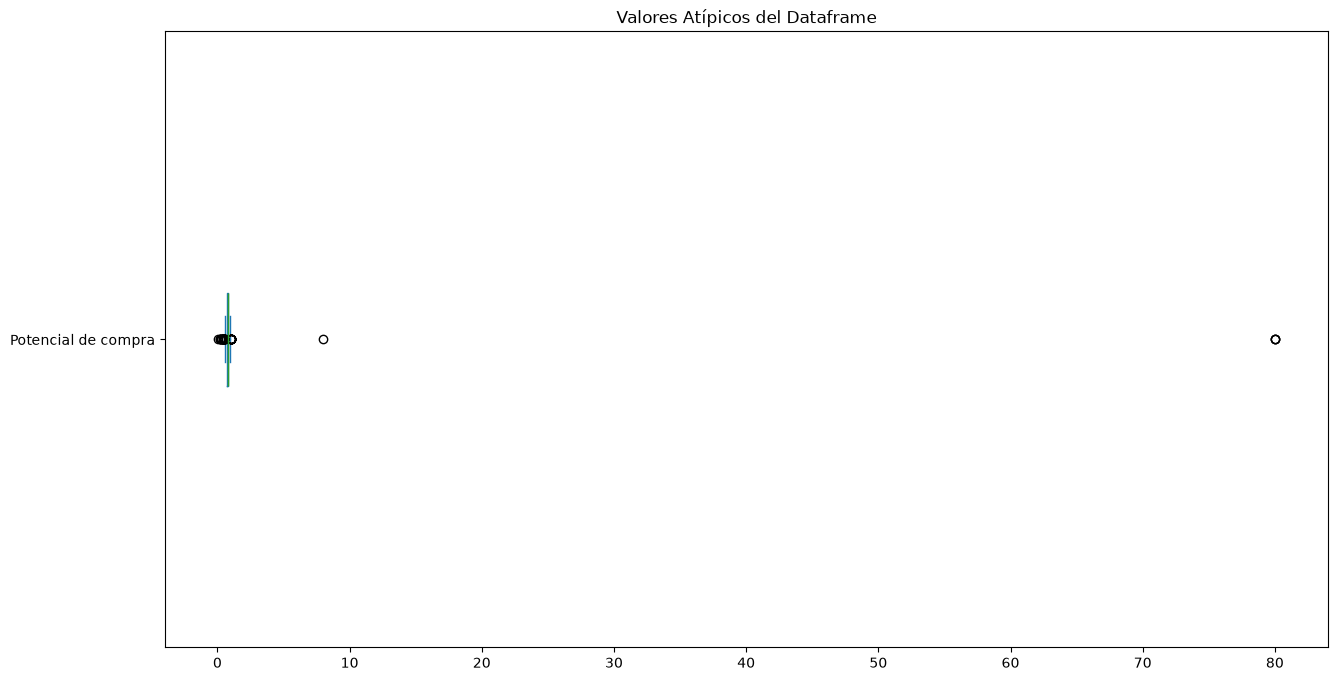

In [14]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas['Potencial de compra'].plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**Se observó que los outliers de potencial de compra es debido a que son typos en el excel, por lo que se van a corregir**

In [15]:
#Se remplazan el 1, 8 y 80 por .1, .8 y .80 respectivamente
cuantitativas['Potencial de compra'] = cuantitativas['Potencial de compra'].replace([1, 8, 80], [0.1, 0.8, 0.80])

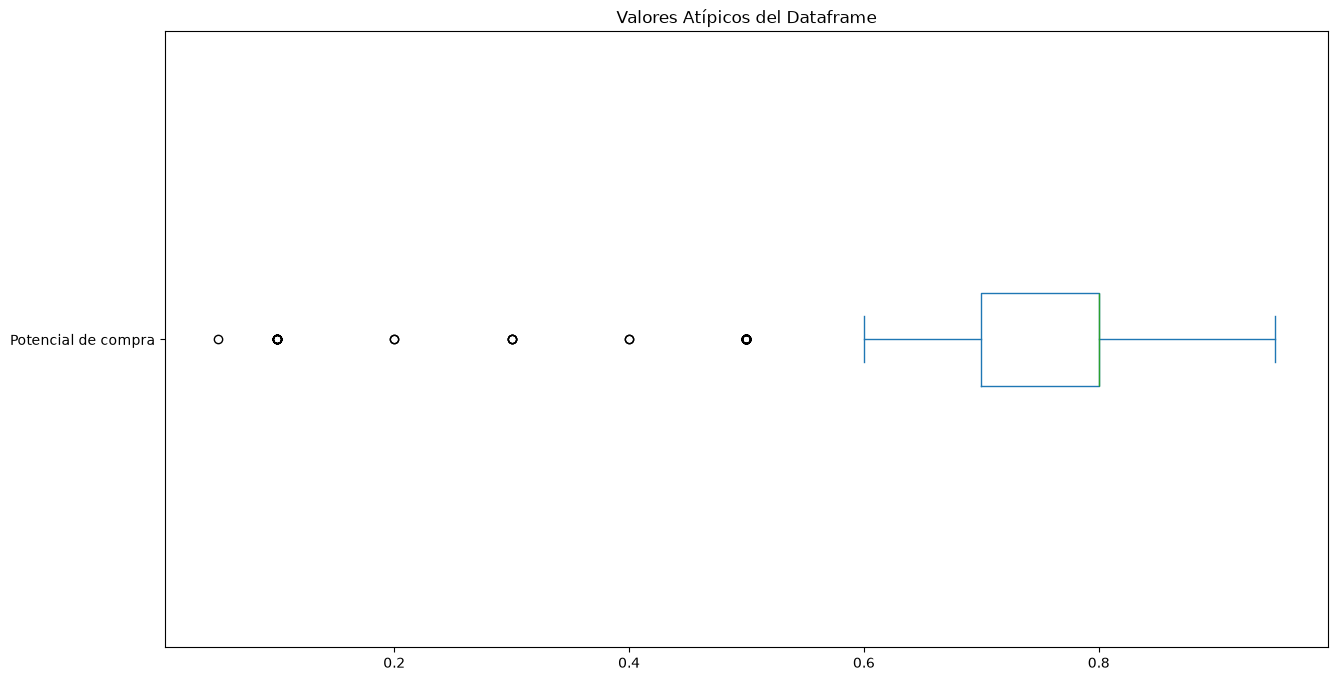

In [16]:
#Se corrobora que se hayan remplazado los valores
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas['Potencial de compra'].plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

<Figure size 1500x800 with 0 Axes>

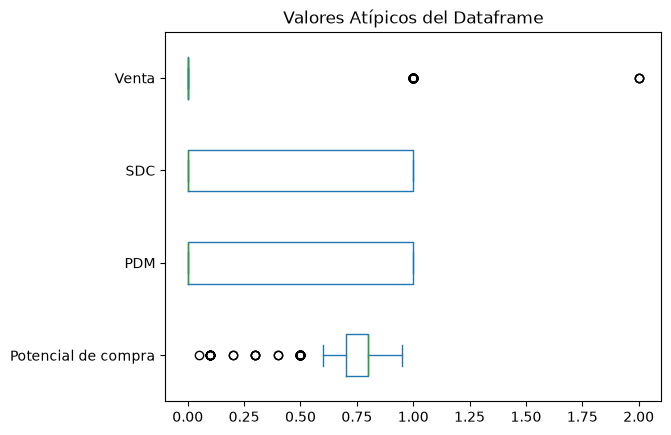

In [17]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [18]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Potencial de compra    1.164333
PDM                    1.990404
SDC                    1.869347
Venta                  1.019530
dtype: float64
Limite inferior permitido Potencial de compra    0.264896
PDM                   -1.011176
SDC                   -1.071127
Venta                 -0.829619
dtype: float64


In [19]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data1= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data1

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,1.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
669,0.80,1.0,1.0,0.0
670,0.50,0.0,0.0,0.0
671,0.50,1.0,0.0,0.0
672,NaN,1.0,1.0,1.0


In [20]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data1.isnull().sum()
valores_nulos

Potencial de compra    20
PDM                     0
SDC                     0
Venta                   3
dtype: int64

In [21]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data1.copy()
data_clean=data_clean.fillna(round(data1.mean(),1))
data_clean

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,1.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
669,0.80,1.0,1.0,0.0
670,0.50,0.0,0.0,0.0
671,0.50,1.0,0.0,0.0
672,0.70,1.0,1.0,1.0


In [22]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

Potencial de compra    0
PDM                    0
SDC                    0
Venta                  0
dtype: int64

**PROCEDIMIENTO "CUANTILES" PARA SUSTITUIR OUTLIERS EN DATAFRAME**

In [23]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Potencial de compra    0.95
PDM                    2.50
SDC                    2.50
Venta                  0.00
dtype: float64
Limite inferior permitido Potencial de compra    0.55
PDM                   -1.50
SDC                   -1.50
Venta                  0.00
dtype: float64


In [24]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,NaN,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
669,0.80,1.0,1.0,0.0
670,NaN,0.0,0.0,0.0
671,NaN,1.0,0.0,0.0
672,NaN,1.0,1.0,NaN


In [25]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

Potencial de compra    71
PDM                     0
SDC                     0
Venta                  61
dtype: int64

In [26]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),1))
data2_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.80,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
669,0.80,1.0,1.0,0.0
670,0.80,0.0,0.0,0.0
671,0.80,1.0,0.0,0.0
672,0.80,1.0,1.0,0.0


In [27]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data2_iqr], axis=1)
Datos_limpios

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Potencial de compra,PDM,SDC,Venta
0,Saul,2030-06-19 00:00:00,Guillermo,Sin Telefono,Finalizado,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",0.90,1.0,0.0,0.0
1,Saul,2030-06-19 00:00:00,Roberto,Sin Telefono,Finalizado,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,0.80,0.0,0.0,0.0
2,Saul,2030-06-19 00:00:00,Irving,Sin Telefono,Finalizado,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,0.85,0.0,0.0,0.0
3,Saul,2030-06-19 00:00:00,Oswaldo,Sin Telefono,Venta,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",0.90,0.0,0.0,0.0
4,Saul,2030-06-19 00:00:00,Rodrigo,Sin Telefono,Finalizado,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,0.90,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,Ana,2026-07-22,Maira Escalante,Sin Telefono,Activo,Pedro Antonio,No responde,No responde,No responde,No responde,No responde,0.80,1.0,1.0,0.0
670,Ignacio,2026-07-22,Zaira Macip,Sin Telefono,Activo,Aurelio,No responde,No responde,No responde,No responde,No responde,0.80,0.0,0.0,0.0
671,Ignacio,2026-07-27,Julio Hernandez,Sin Telefono,Activo,Victor,No responde,No responde,No responde,No responde,No responde,0.80,1.0,0.0,0.0
672,Ignacio,2026-07-24,Xhunaxhi Vicente,Sin Telefono,Activo,Ignacio,No responde,No responde,No responde,No responde,No responde,0.80,1.0,1.0,0.0


In [28]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Telefono                                    0
Estatus de Lead                             0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
dtype: int64

In [30]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Citas_digital_sin_outliers.csv")